In [1]:
# pip install -q transformers datasets accelerate torch scikit-learn pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, TrainingArguments, Trainer, set_seed)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay)

set_seed(123)

# Load Data & Understand it

In [3]:
imdb = load_dataset("stanfordnlp/imdb")
print(imdb)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


#### The dataset provides 25,000 labeled training reviews and 25,000 labeled test reviews
#### labels are negative 0 and positive 1

In [4]:
print(imdb["train"][0])

{'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far be

#### So every observation contains a text as the movie review and a label as the sentiment (0,1)

In [5]:
train_labels = pd.Series(imdb["train"]["label"])
print(train_labels.value_counts(normalize=True) * 100)
test_labels = pd.Series(imdb["test"]["label"])
print(test_labels.value_counts(normalize=True) * 100)

0    50.0
1    50.0
Name: proportion, dtype: float64
0    50.0
1    50.0
Name: proportion, dtype: float64


# Create train, Validation, and Test Data

##### As I want to run my CPU, I'm using only a smaller sample

In [6]:
small_train = imdb["train"].shuffle(seed=123).select(range(3000))
split = small_train.train_test_split(test_size=0.20, seed=123, stratify_by_column="label")
train_data = split["train"]
val_data = split["test"]
test_split = imdb["test"].train_test_split(train_size=1000, seed=123, stratify_by_column="label")
test_data = test_split["train"]

print("\nTraining:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))


Training: 2400
Validation: 600
Test: 1000


# Tokenize

#### Model selection: DistilBERT was selected as the pretrained Transformer because the task is English text classification and the model is relatively lightweight and CPU-based experimentation.

#### Tokenizer selection: After selecting DistilBERT, its matching tokenizer is used because the model was pretrained using that tokenizer's vocabulary and tokenization rules.

In [7]:
tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-uncased")

#### Let's see an example

In [8]:
sample_text = train_data[0]["text"]
encoded = tokenizer(sample_text, truncation=True, max_length=64)
print("\nOriginal text:")
print(sample_text[:300])

print("\nFirst 20 token IDs:")
print(encoded["input_ids"][:20])

print("\nFirst 20 tokens:")
print(tokenizer.convert_ids_to_tokens(encoded["input_ids"][:20]))

print("\nFirst 20 attention-mask values:")
print(encoded["attention_mask"][:20])


Original text:
Carlos Mencia was excellent this is hour special. He was working hard to show everybody he was the real deal. I know people have said he's stolen material in this special, but that is not true. Carlos brings comedy up front the way he wants it, not how anyone else wants it, that is why he is so good

First 20 token IDs:
[101, 5828, 2273, 7405, 2001, 6581, 2023, 2003, 3178, 2569, 1012, 2002, 2001, 2551, 2524, 2000, 2265, 7955, 2002, 2001]

First 20 tokens:
['[CLS]', 'carlos', 'men', '##cia', 'was', 'excellent', 'this', 'is', 'hour', 'special', '.', 'he', 'was', 'working', 'hard', 'to', 'show', 'everybody', 'he', 'was']

First 20 attention-mask values:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


### Tokenize the whole dataset

In [9]:
token_lengths = [len(tokenizer(text)["input_ids"]) for text in train_data["text"]]
print("Average length:", np.mean(token_lengths))
print("Reviews longer than 128:", np.mean(np.array(token_lengths) > 128))
print("Reviews longer than 256:", np.mean(np.array(token_lengths) > 256))
print("Reviews longer than 512:", np.mean(np.array(token_lengths) > 512))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (711 > 512). Running this sequence through the model will result in indexing errors


Average length: 318.44708333333335
Reviews longer than 128: 0.9
Reviews longer than 256: 0.45375
Reviews longer than 512: 0.15583333333333332


#### So, I'll use 512 tokes. 

In [10]:
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, max_length=512)

tokenized_train = train_data.map(tokenize_batch, batched=True, remove_columns=["text"])
tokenized_val = val_data.map(tokenize_batch, batched=True, remove_columns=["text"])
tokenized_test = test_data.map(tokenize_batch, batched=True, remove_columns=["text"])

### Padding
#### Reviews in the same batch may have different lengths. But when putting them into the same batch, tensors need compatible dimensions.

In [11]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

### Load DistilBERT

In [12]:
id2label = {0: "NEGATIVE", 1: "POSITIVE"}
label2id = {"NEGATIVE": 0, "POSITIVE": 1}
model = AutoModelForSequenceClassification.from_pretrained("distilbert/distilbert-base-uncased", num_labels=2, id2label=id2label, label2id=label2id)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
# Freeze the pretrained DistilBERT layers so that only the new sentiment-classification layers are trained in this first experiment.
for parameter in model.distilbert.parameters():
    parameter.requires_grad = False

# Define evaluation metrics

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1) #As logit is a score

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

# Train the Model

#### Hugging Face's `Trainer` provides a built-in PyTorch training loop for Transformer models. Calling `trainer.train()` performs the forward pass, loss calculation, backpropagation, and parameter updates for each batch.

#### These are the same basic training steps used in the standard PyTorch neural network that I did in my previous work.

In [15]:
# I want the model to be trained for 3 epochs using batches of 16 reviews and a learning rate of 0.0001. 
# Validation performance is evaluated after each epoc.
training_args = TrainingArguments(
    output_dir="distilbert_sentiment_model",
    learning_rate=0.0001,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy", #it can be "accuracy"
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    use_cpu=True,
    dataloader_pin_memory=False,
    seed=123
)

In [16]:
trainer = Trainer(
    model=model, #tells it what neural network to train
    args=training_args, #gives it all our settings
    train_dataset=tokenized_train, #data used to update weights
    eval_dataset=tokenized_val, #data used to evaluate after each epoch
    processing_class=tokenizer, #tells Trainer which tokenizer belongs to the model
    data_collator=data_collator, #handles batch padding
    compute_metrics=compute_metrics #tells Trainer how to calculate Accuracy, Precision, Recall, and F1
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.534516,0.853333,0.864583,0.835570,0.849829
2,No log,0.457831,0.868333,0.873720,0.859060,0.866328
3,No log,0.437330,0.863333,0.872414,0.848993,0.860544


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=450, training_loss=0.547930908203125, metrics={'train_runtime': 1027.3306, 'train_samples_per_second': 7.008, 'train_steps_per_second': 0.438, 'total_flos': 945291496415424.0, 'train_loss': 0.547930908203125, 'epoch': 3.0})

# Check Validation

In [18]:
validation_results = trainer.evaluate()

print("\nValidation Results:")
print(validation_results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.457831,3,0.868333,0.873720,0.859060,0.866328



Validation Results:
{'eval_loss': 0.4578312635421753, 'eval_accuracy': 0.8683333333333333, 'eval_precision': 0.8737201365187713, 'eval_recall': 0.8590604026845637, 'eval_f1': 0.8663282571912013}


# Final Test Predictions

In [19]:
test_output = trainer.predict(tokenized_test)

test_logits = test_output.predictions
test_true = test_output.label_ids
test_predictions = np.argmax(test_logits, axis=1)
test_probabilities = torch.softmax(torch.tensor(test_logits), dim=1).numpy()

In [20]:
# For checking
print(test_logits[0])
print(test_probabilities[0])
print(test_probabilities[0].sum())

[-0.36542654  0.40004456]
[0.3174596  0.68254036]
1.0


In [21]:
accuracy = accuracy_score(test_true, test_predictions)
precision = precision_score(test_true, test_predictions)
recall = recall_score(test_true, test_predictions)
f1 = f1_score(test_true, test_predictions)

print("\nFinal Test Results:")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")


Final Test Results:
Accuracy:  0.819
Precision: 0.833
Recall:    0.798
F1 Score:  0.815



Confusion Matrix:
[[420  80]
 [101 399]]


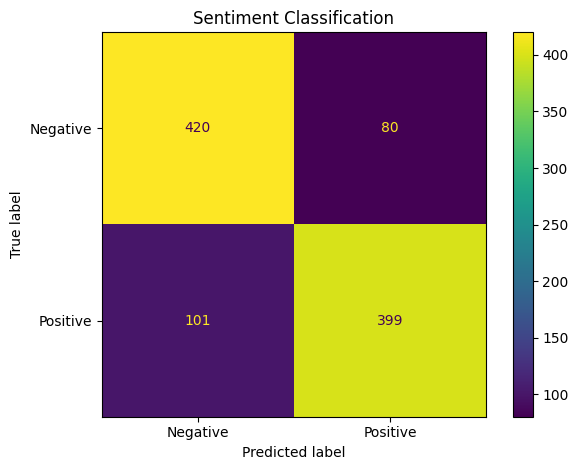

In [22]:
confusion = confusion_matrix(test_true, test_predictions)

print("\nConfusion Matrix:")
print(confusion)

display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=["Negative", "Positive"])

display.plot()
plt.title("Sentiment Classification")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()